In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Dataset Information:")
print(df.info())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Dataset Shape:
(891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


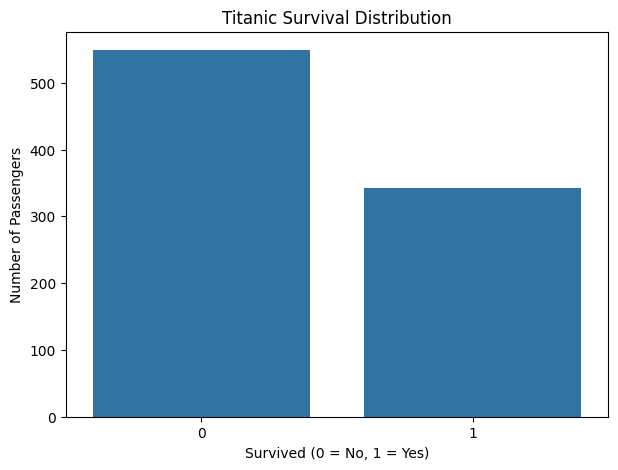

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Survived")

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

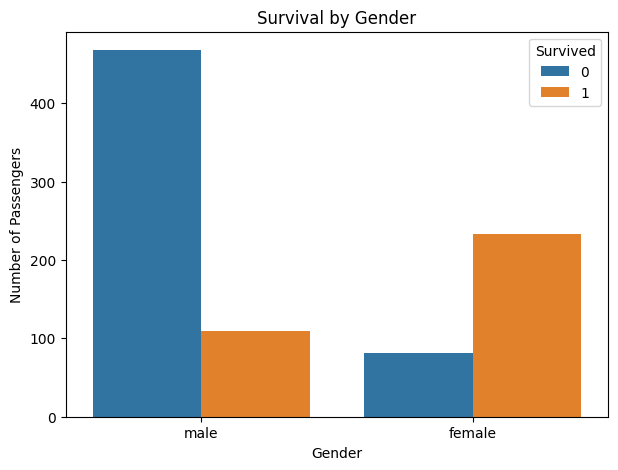

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

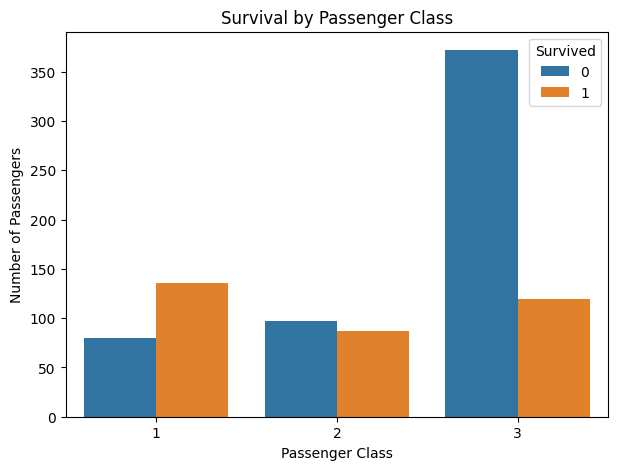

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

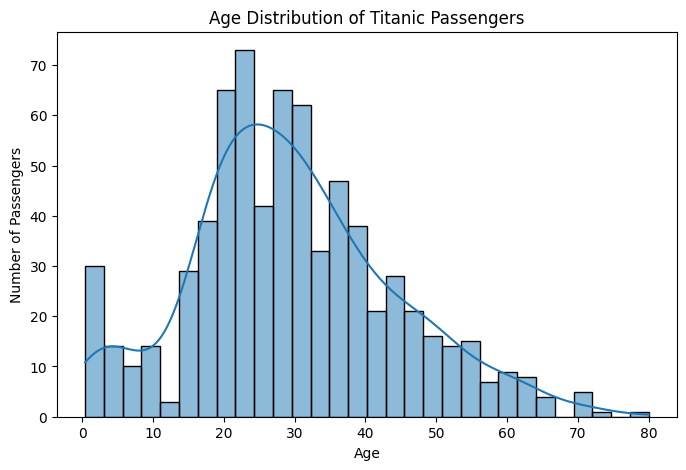

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

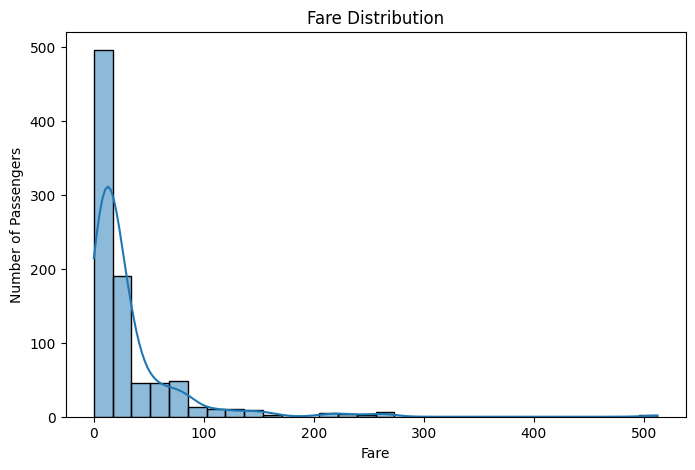

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Fare", bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

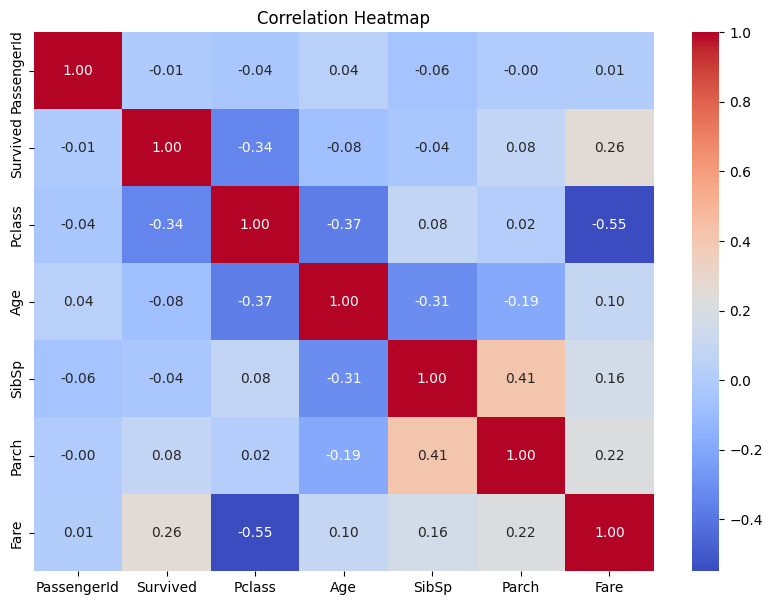

In [13]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [14]:
data = df.copy()

In [15]:
data["CabinAvailable"] = data["Cabin"].notna().astype(int)

data[["Cabin", "CabinAvailable"]].head()

,Cabin,CabinAvailable
0,NaN,0
1,C85,1
2,NaN,0
3,C123,1
4,NaN,0


In [16]:
data["Age"] = data["Age"].fillna(data["Age"].median())

In [17]:
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

In [18]:
model_data = data.drop(
    columns=["PassengerId", "Name", "Ticket", "Cabin"]
)

model_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinAvailable
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0


In [19]:
model_data = pd.get_dummies(
    model_data,
    columns=["Sex", "Embarked"],
    drop_first=True
)

model_data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,CabinAvailable,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,True,False,True
1,1,1,38.0,1,0,71.2833,1,False,False,False
2,1,3,26.0,0,0,7.9250,0,False,False,True
3,1,1,35.0,1,0,53.1000,1,False,False,True
4,0,3,35.0,0,0,8.0500,0,True,False,True


In [20]:
X = model_data.drop("Survived", axis=1)
y = model_data["Survived"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (891, 9)
Target: (891,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 9)
Testing data: (179, 9)


In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [23]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy, 4))

Logistic Regression Accuracy: 0.8156


In [24]:
print("Classification Report:")
print(classification_report(y_test, logistic_predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



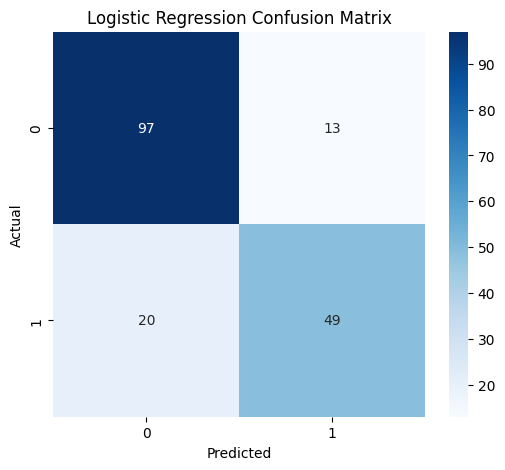

In [25]:
cm = confusion_matrix(y_test, logistic_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:",
      round(rf_accuracy, 4))

Random Forest Accuracy: 0.7877


In [27]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.815642
1,Random Forest,0.787709


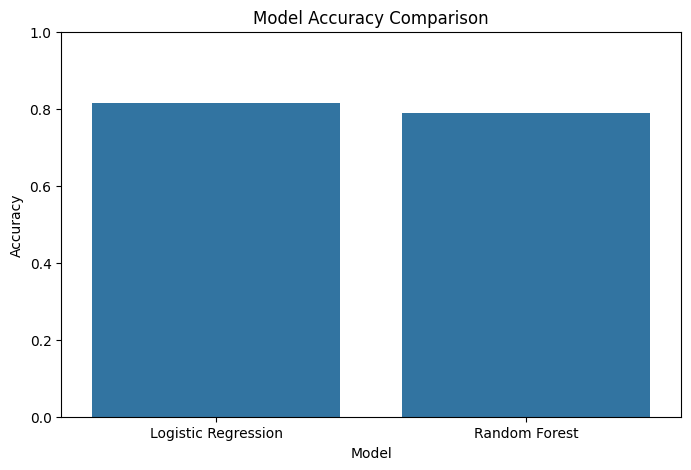

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [29]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Fare,0.261224
6,Sex_male,0.254808
1,Age,0.237161
0,Pclass,0.074620
5,CabinAvailable,0.051730
2,SibSp,0.048618
3,Parch,0.038996
8,Embarked_S,0.024820
7,Embarked_Q,0.008023


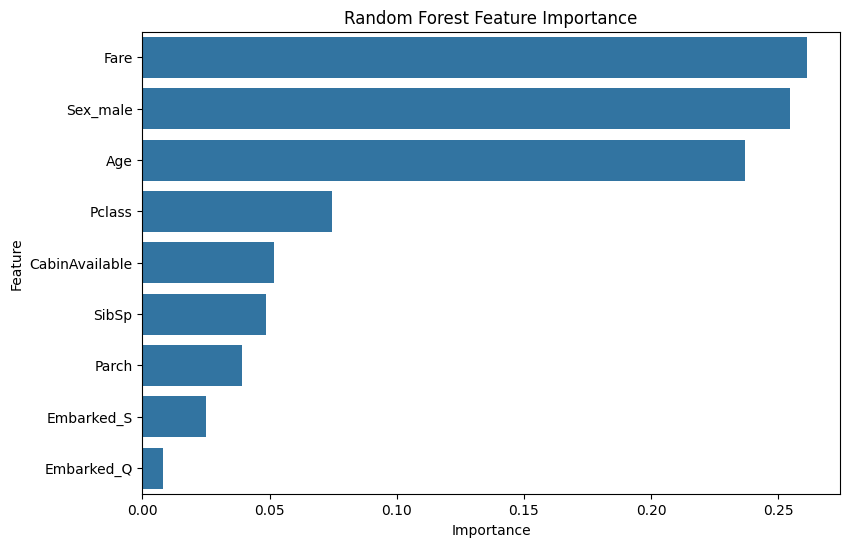

In [30]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [31]:
cluster_data = data[
    ["Age", "Fare", "SibSp", "Parch", "Pclass"]
].copy()

cluster_data.head()

,Age,Fare,SibSp,Parch,Pclass
0,22.0,7.2500,1,0,3
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,3
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,3


In [32]:
cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(
    cluster_data
)

print("Clustering data prepared.")

Clustering data prepared.


In [33]:
inertia = []

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_scaled)

    inertia.append(kmeans.inertia_)

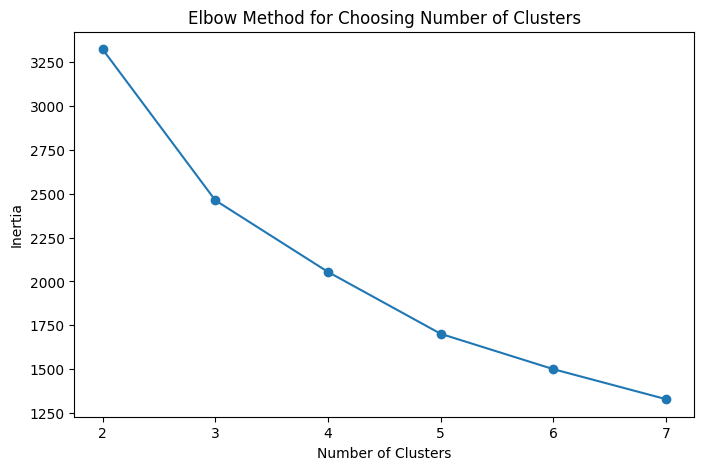

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 8),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Choosing Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [35]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(cluster_scaled)

cluster_data["Cluster"] = clusters

cluster_data.head()

,Age,Fare,SibSp,Parch,Pclass,Cluster
0,22.0,7.2500,1,0,3,1
1,38.0,71.2833,1,0,1,2
2,26.0,7.9250,0,0,3,1
3,35.0,53.1000,1,0,1,2
4,35.0,8.0500,0,0,3,1


In [36]:
silhouette = silhouette_score(
    cluster_scaled,
    clusters
)

print("Silhouette Score:",
      round(silhouette, 4))

Silhouette Score: 0.417


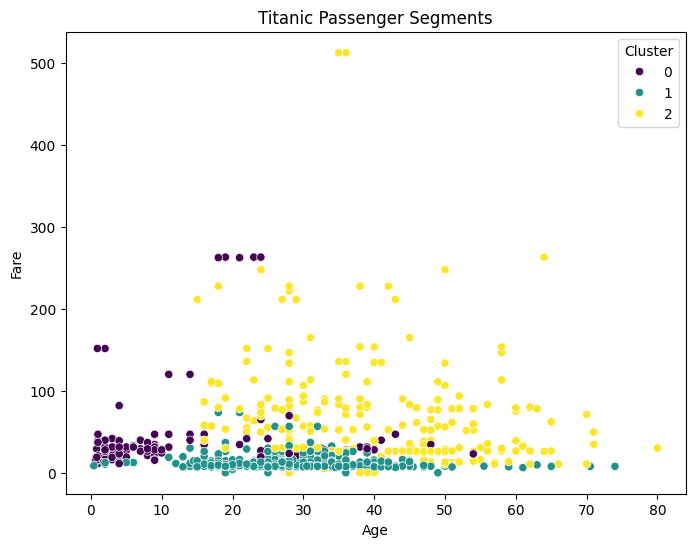

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=cluster_data,
    x="Age",
    y="Fare",
    hue="Cluster",
    palette="viridis"
)

plt.title("Titanic Passenger Segments")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

In [38]:
cluster_summary = cluster_data.groupby("Cluster").mean()

cluster_summary

,Age,Fare,SibSp,Parch,Pclass
Cluster,,,,,
0,15.088636,45.921856,2.336364,1.936364,2.572727
1,27.788598,12.191819,0.225092,0.110701,2.771218
2,39.497908,71.274390,0.364017,0.280335,1.138075


In [39]:
print("===== FINAL PROJECT SUMMARY =====")

print("\nSupervised Learning:")
print(results)

print("\nBest Supervised Model:")

if rf_accuracy > logistic_accuracy:
    print("Random Forest")
else:
    print("Logistic Regression")

print("\nClustering Silhouette Score:",
      round(silhouette, 4))

===== FINAL PROJECT SUMMARY =====

Supervised Learning:
                 Model  Accuracy
0  Logistic Regression  0.815642
1        Random Forest  0.787709

Best Supervised Model:
Logistic Regression

Clustering Silhouette Score: 0.417
